In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt



In [7]:
#Using GPU if avalilable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Loading the MNIST dataset.
# Normalizing to help the model converge faster.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)



Using device: cuda


In [8]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        # The images are 28x28, so we flatten them into a 784-length vector
        self.flatten = nn.Flatten()
        self.hidden = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.output = nn.Linear(128, 10) # 10 output classes for digits 0-9

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        out = self.output(x)
        return out


model = SimpleNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
losses = []

print("Starting training...")
for epoch in range(epochs):
    running_loss = 0.0
    model.train()

    for data, targets in train_loader:
        #pushing data to the GPU
        data, targets = data.to(device), targets.to(device)


        optimizer.zero_grad()

        preds = model(data)
        loss = criterion(preds, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")



Starting training...
Epoch 1/10 | Loss: 0.3806
Epoch 2/10 | Loss: 0.1966
Epoch 3/10 | Loss: 0.1416
Epoch 4/10 | Loss: 0.1121
Epoch 5/10 | Loss: 0.0968
Epoch 6/10 | Loss: 0.0842
Epoch 7/10 | Loss: 0.0741
Epoch 8/10 | Loss: 0.0659
Epoch 9/10 | Loss: 0.0609
Epoch 10/10 | Loss: 0.0535


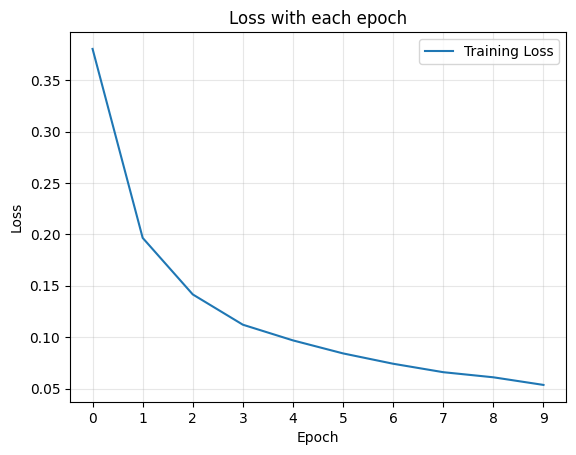

In [11]:
# Plotting the losses
plt.plot(losses, label="Training Loss")
plt.title("Loss with each epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(epochs))
plt.grid(alpha=0.3)
plt.legend()
plt.show()



In [10]:
# Quick test loop to check accuracy
model.eval()
correct = 0
total = 0

with torch.no_grad(): # to save memory since we aren't training right now
    for data, targets in test_loader:
        data, targets = data.to(device), targets.to(device)
        preds = model(data)

        # Grab the index of the highest probability
        _, predicted_classes = torch.max(preds, dim=1)
        total += targets.size(0)
        correct += (predicted_classes == targets).sum().item()

print(f"Final Test Accuracy: {100 * correct / total:.2f}%")

Final Test Accuracy: 97.37%


# **Backpropogation:**

Neural networks learn via weights and biases given to each node. After every epoch, loss or the error in the model's predictions in calculated. The model is then refined using backpropogation where chain rule is used to calculate the rate at which loss changes in response to any change to a specific weight or bias in the network.

During backpropogation the model calculates the gradient of the loss function for every parameter, or the 'direction to step in' to reduce the loss. Then these parameters are changed accordingly by the learning rate factor and so that the model learns.

And since as we ggo towards higher accuracy, this 'gradient becomes less steep' and so the change in loss becomes more slow as the graph above also shows.